# Notebook 2: Image Preprocessing 
This notebook prepares the rice-leaf images for deep-learning model training.
Main tasks:
- load the train, validation and test metadata
- Convert disease labels into numerical values
- Resize and normalize images
- Apply augmentation to training images
- Create Pytorch Dataset Objects
- Create Dataloader objects
- Visualize processed images

In [1]:
from pathlib import Path
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [2]:
# Set a random Seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print("Random seed:", SEED)

Random seed: 42


In [3]:
# Define Project paths
PROJECT_ROOT = Path("C:/Projects/16_Rice_Guard")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

TRAIN_CSV = PROCESSED_DIR / "train_metadata.csv"
VALIDATION_CSV = PROCESSED_DIR / "validation_metadata.csv"
TEST_CSV = PROCESSED_DIR / "test_metadata.csv"

print("Train metadata exists:", TRAIN_CSV.exists())
print("Validation metadata exists:", VALIDATION_CSV.exists())
print("Test metadata exists:", TEST_CSV.exists())

Train metadata exists: True
Validation metadata exists: True
Test metadata exists: True


In [4]:
# Load the metadata
train_df = pd.read_csv(TRAIN_CSV)
validation_df = pd.read_csv(VALIDATION_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Training samples:", len(train_df))
print("Validation samples:", len(validation_df))
print("Test samples:", len(test_df))

display(train_df.head())

Training samples: 7284
Validation samples: 1561
Test samples: 1562


,image_id,label,variety,age,image_path,image_exists
0,105424.jpg,bacterial_leaf_streak,Zonal,70,C:\Projects\16_Rice_Guard\data\raw\train_image...,True
1,109398.jpg,brown_spot,ADT45,65,C:\Projects\16_Rice_Guard\data\raw\train_image...,True
2,101702.jpg,bacterial_leaf_blight,ADT45,55,C:\Projects\16_Rice_Guard\data\raw\train_image...,True
3,108319.jpg,brown_spot,ADT45,66,C:\Projects\16_Rice_Guard\data\raw\train_image...,True
4,103365.jpg,blast,Zonal,70,C:\Projects\16_Rice_Guard\data\raw\train_image...,True


In [5]:
# Check the required columns
required_columns = {"image_id", "label", "image_path"}

for dataset_name, dataset_df in {
    "train": train_df,
    "validation": validation_df,
    "test": test_df
}.items():

    missing_columns = required_columns - set(dataset_df.columns)

    if missing_columns:
        raise ValueError(
            f"{dataset_name} dataset is missing columns: {missing_columns}"
        )

print("All required columns are available.")

All required columns are available.


In [6]:
# Convert image paths into Path objects
for dataset_df in [train_df, validation_df, test_df]:
    dataset_df["image_path"] = dataset_df['image_path'].apply(Path)

print(train_df.loc[0, "image_path"])
print("First image exists:", train_df.loc[0, "image_path"].exists())

C:\Projects\16_Rice_Guard\data\raw\train_images\bacterial_leaf_streak\105424.jpg
First image exists: True


In [7]:
# Create the label mapping
class_names = sorted(train_df["label"].unique())

class_to_index = {
    class_names: index 
    for index, class_names in enumerate(class_names)
}

index_to_class = {
    index: class_name
    for class_name, index in class_to_index.items()
}

print("Number of classes:", len(class_names))
print("\nClass mapping:")

for class_name, index in class_to_index.items():
    print(f"Z{index}: {class_name}")

Number of classes: 10

Class mapping:
Z0: bacterial_leaf_blight
Z1: bacterial_leaf_streak
Z2: bacterial_panicle_blight
Z3: blast
Z4: brown_spot
Z5: dead_heart
Z6: downy_mildew
Z7: hispa
Z8: normal
Z9: tungro


In [8]:
# Add numerical labels
for dataset_df in [train_df, validation_df, test_df]:
    dataset_df["target"] = dataset_df["label"].map(class_to_index)
print(train_df[["label", "target"]].head())

                   label  target
0  bacterial_leaf_streak       1
1             brown_spot       4
2  bacterial_leaf_blight       0
3             brown_spot       4
4                  blast       3


In [9]:
# Verify the labels
for dataset_name, dataset_df in {
    "train": train_df,
    "validation": validation_df,
    "test": test_df
}.items():
    missing_targets = dataset_df["target"].isna().sum()
    print(
        f"{dataset_name}:"
        f"{dataset_df['label'].nunique()} classes,"
        f"{missing_targets} missing targets"
    )

train:10 classes,0 missing targets
validation:10 classes,0 missing targets
test:10 classes,0 missing targets


In [10]:
# Save the label mapping
LABEL_MAPPING_PATH = PROCESSED_DIR / "label_mapping.json"

with open(LABEL_MAPPING_PATH, "w", encoding="utf-8") as file:
    json.dump(class_to_index, file, indent=4)

print("Label mapping saved to:")
print(LABEL_MAPPING_PATH)

Label mapping saved to:
C:\Projects\16_Rice_Guard\data\processed\label_mapping.json


In [11]:
# Define image setting
IMAGE_SIZE = 224
BATCH_SIZE = 32

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)

Image size: 224
Batch size: 32


In [13]:
# Create training transformations
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        size=IMAGE_SIZE,
        scale=(0.80, 1.00)
    ),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
        hue=0.02
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )

])

In [14]:
# Create validation and test transformations
evaluation_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

In [15]:
# Create a custom PyTorch Dataset
class RiceDiseaseDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image_path = Path(row["image_path"])
        target = int(row["target"])

        try:
            with Image.open(image_path) as image:
                image = image.convert("RGB")

                if self.transform is not None:
                    image = self.transform(image)

        except Exception as error:
            raise RuntimeError(
                f"Could not load image: {image_path}"
            ) from error

        return image, target

In [16]:
# Create the three Dataset objects
train_dataset = RiceDiseaseDataset(
    dataframe=train_df,
    transform=train_transform
)

validation_dataset = RiceDiseaseDataset(
    dataframe=validation_df,
    transform=evaluation_transform
)

test_dataset = RiceDiseaseDataset(
    dataframe=test_df,
    transform=evaluation_transform
)


print("Training dataset:", len(train_dataset))
print("Validation dataset:", len(validation_dataset))
print("Test dataset:", len(test_dataset))

Training dataset: 7284
Validation dataset: 1561
Test dataset: 1562


In [17]:
# Test one image
sample_image, sample_target = train_dataset[0]

print("Image tensor shape:", sample_image.shape)
print("Target number:", sample_target)
print("Target class:", index_to_class[sample_target])

Image tensor shape: torch.Size([3, 224, 224])
Target number: 1
Target class: bacterial_leaf_streak


In [18]:
# Create DataLoader
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

PIN_MEMORY = DEVICE.type == "cuda"

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=PIN_MEMORY
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=PIN_MEMORY
)
print("Device:", DEVICE)
print("Training batches:", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Test batches:", len(test_loader))

Device: cpu
Training batches: 228
Validation batches: 49
Test batches: 49


In [19]:
# Inspect one batch
batch_images, batch_targets = next(iter(train_loader))
print("Batch image shape:", batch_images.shape)
print("Batch target shape:", batch_targets.shape)

print("First five targets:")
print(batch_targets[:5])

Batch image shape: torch.Size([32, 3, 224, 224])
Batch target shape: torch.Size([32])
First five targets:
tensor([1, 6, 6, 0, 8])


In [20]:
# Create an inverse-normalization function
mean_tensor = torch.tensor(
    IMAGENET_MEAN
). view(3, 1, 1)

std_tensor = torch.tensor(
    IMAGENET_STD
).view(3, 1, 1)

def denormalize_image(image_tensor):
    image = image_tensor.cpu() * std_tensor + mean_tensor
    return torch.clamp(image, 0, 1)

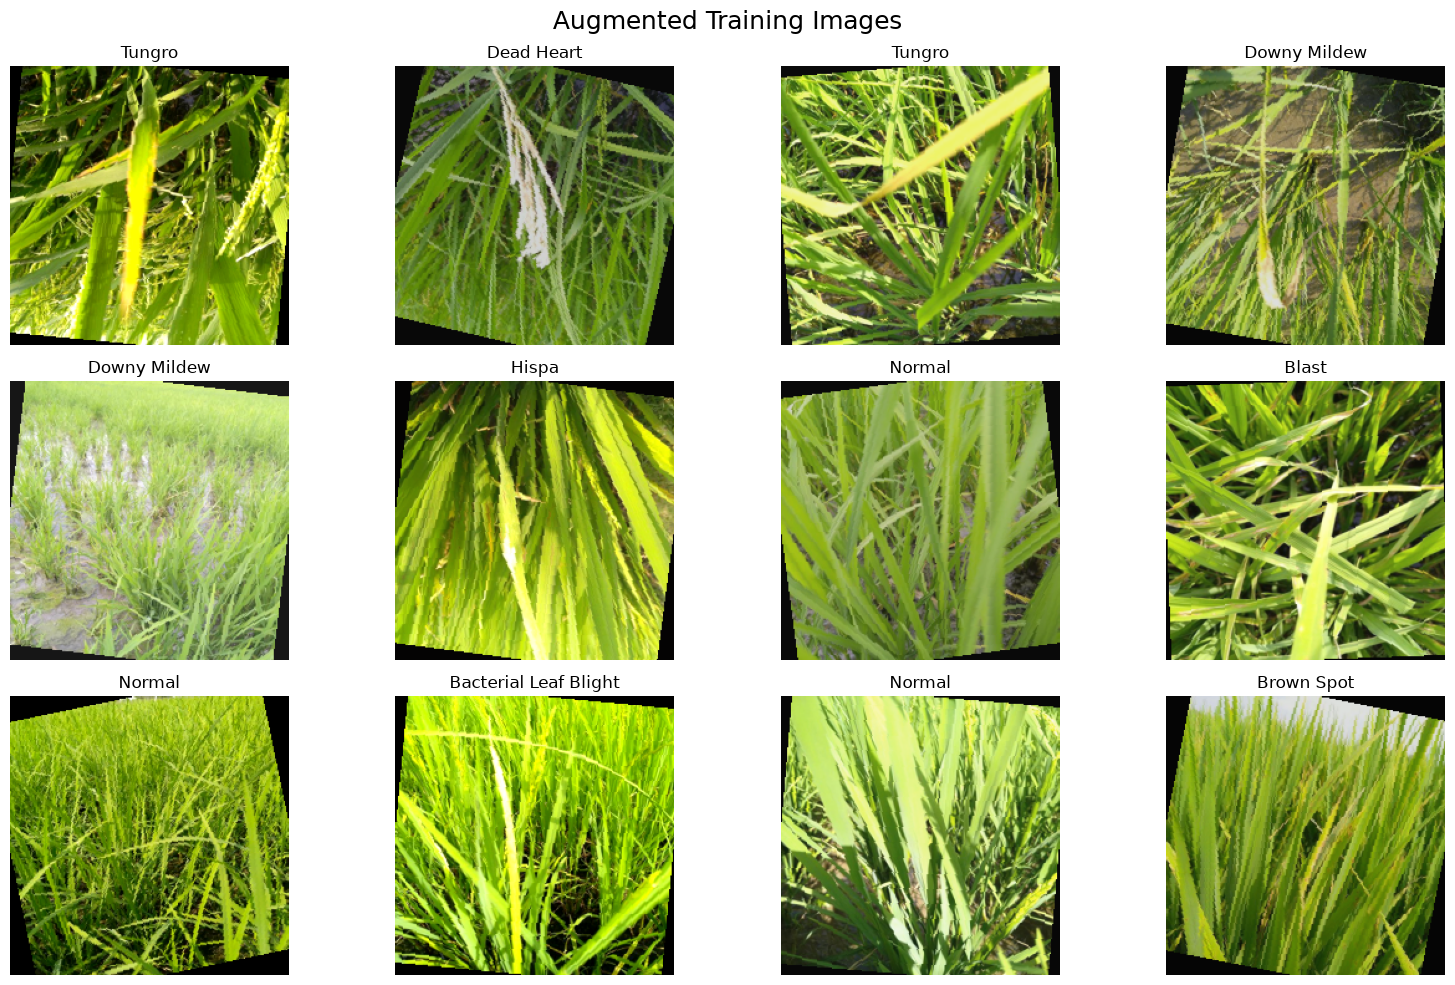

In [21]:
# Display one processed batch
images, targets = next(iter(train_loader))

plt.figure(figsize=(16, 10))

number_of_images = min(12, len(images))

for index in range(number_of_images):
    image = denormalize_image(images[index])
    image = image.permute(1, 2, 0).numpy()

    label_name = index_to_class[int(targets[index])]

    plt.subplot(3, 4, index + 1)
    plt.imshow(image)
    plt.title(label_name.replace("_", " ").title())
    plt.axis("off")

plt.suptitle(
    "Augmented Training Images",
    fontsize=18
)

plt.tight_layout()
plt.show()

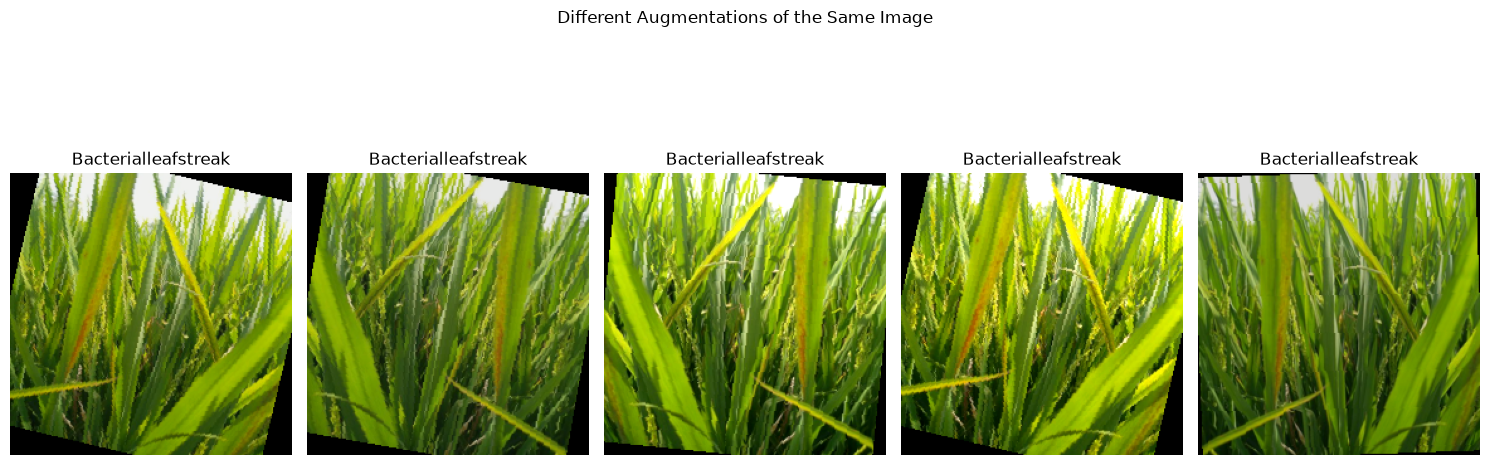

In [22]:
# Compare repeated augmentation
sample_index = 0
plt.figure(figsize=(15,6))

for index in range(5):
    augmented_image, target = train_dataset[sample_index]

    visible_image = denormalize_image(
        augmented_image
    ).permute(1, 2, 0).numpy()

    plt.subplot(1, 5, index + 1)
    plt.imshow(visible_image)
    plt.title(
        index_to_class[target]
        .replace("_", "")
        .title()
    )
    plt.axis("off")

plt.suptitle("Different Augmentations of the Same Image")
plt.tight_layout()
plt.show()

In [24]:
# Calculate class weights
class_counts = (
    train_df["target"]
    .value_counts()
    .sort_index()
)

number_of_samples = len(train_df)
number_of_classes = len(class_names)

class_weights = (
    number_of_samples
    / (number_of_classes * class_counts)
)

class_weights_tensor = torch.tensor(
    class_weights.values,
    dtype=torch.float32
)

class_weights_df = pd.DataFrame({
    "class_index": range(number_of_classes),
    "class_name": class_names,
    "image_count": class_counts.values,
    "class_weight": class_weights.values
})

display(class_weights_df)

,class_index,class_name,image_count,class_weight
0,0,bacterial_leaf_blight,335,2.174328
1,1,bacterial_leaf_streak,266,2.738346
2,2,bacterial_panicle_blight,236,3.086441
3,3,blast,1216,0.599013
4,4,brown_spot,675,1.079111
5,5,dead_heart,1009,0.721903
6,6,downy_mildew,434,1.678341
7,7,hispa,1116,0.652688
8,8,normal,1235,0.589798
9,9,tungro,762,0.955906


In [25]:
# Save class weights
CLASS_WEIGHTS_PATH = PROCESSED_DIR / "class_weights.csv"

class_weights_df.to_csv(
    CLASS_WEIGHTS_PATH,
    index=False
)

print("Class weights saved to:")
print(CLASS_WEIGHTS_PATH)

Class weights saved to:
C:\Projects\16_Rice_Guard\data\processed\class_weights.csv


In [26]:
# Final Validation
assert len(train_dataset) == len(train_df)
assert len(validation_dataset) == len(validation_df)
assert len(test_dataset) == len(test_df)

assert batch_images.shape[1:] == (
    3,
    IMAGE_SIZE,
    IMAGE_SIZE
)

assert len(class_to_index) == train_df["label"].nunique()

print("All preprocessing checks passed")

All preprocessing checks passed


## Notebook 2 Summary
In this notebook, the rice-disease images were prepared for deep-learning model development.

### Completed Tasks
- Loaded the training, validation, and internal test metadata
- Converted disease labels into numerical target values
- Saved the class-to-index mapping
- Resized images to 224 x 224 pixels
- Applied ImageNet normalization
- Added moderate training-image augmentation
- Created a custom Pytorch Dataset class
- Created training, validation, and test Dataloaders
- Inspected processed image batches
- Calculate class weights for imbalanced classes

### Training Augemnetation
The training pipeline includes:
- Random resized cropping
- Horizontal flipping
- Occasional vertical flipping
- Small rotations
- Moderate color adjustment
- ImageNet normalization

Validation and test images are only resized and normalized to ensure consistent evaluation.

## DataLoader Configuration
- Batch size: 32
- Training data: shuffled
- Validation and test data: not shuffled
- Image shape: 3 x 224 x 224
- Windows-saFE WORKER Configuration: 'num_workers=0'

### Saved Outputs
- `data/processed/label_mapping.json`
- `data/processed/class_weights.csv`

### Next Step
Notebook 3 will develop and evaluate a baseline Convolutional Neural Network model.
